<a href="https://colab.research.google.com/github/thiilelli/raidium-segmentation/blob/main/raidium-segmentation/notebook%20/raidium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge Raidium — ENS #165
### Segmentation de structures anatomiques avec labels manquants



In [1]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
# Imports & configuration

import gc
import json
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

DRIVE = Path("/content/drive/MyDrive/radium_challenge")
LOCAL = Path("/content/data")      # disque local : rapide, jetable
CACHE = DRIVE / "cache"            # 3 gros .npy, jamais des milliers de PNG
CACHE.mkdir(parents=True, exist_ok=True)

LABEL_CSV = "label_Hnl61pT.csv"
IMG_SIZE = 256
IMG_EXT = {".png", ".PNG", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

SOURCES = [LABEL_CSV, "train-images.zip", "test-images.zip",
           "annotated_labels.json"]

presents = {p.name for p in DRIVE.iterdir()}
manquants = [f for f in SOURCES if f not in presents]

print("Contenu de", DRIVE)
for p in sorted(DRIVE.iterdir()):
    t = f"{p.stat().st_size/1e6:8.1f} Mo" if p.is_file() else "  <dossier>"
    print(f"  {t}  {p.name}")

if manquants:
    raise FileNotFoundError(
        f"Fichiers sources invisibles : {manquants}\n"
        "Si tu les vois sur drive.google.com, le montage est désynchronisé :\n"
        "  drive.flush_and_unmount(), puis Exécution > Redémarrer la session."
    )
print("\nOK — les 4 fichiers sources sont visibles.")

Contenu de /content/drive/MyDrive/radium_challenge
       0.1 Mo  annotated_labels.json
    <dossier>  cache
     267.8 Mo  label_Hnl61pT.csv
      12.8 Mo  test-images.zip
      52.4 Mo  train-images.zip

OK — les 4 fichiers sources sont visibles.


In [5]:
# Chargement avec cache .npy. Tri des fichiers par entier du nom (c'est cet ordre exact qu'il faudra réutiliser pour les colonnes de la soumission)

def find_img_dir(root: Path) -> Path:
    """Trouve le dossier contenant les images (les zips sont souvent imbriqués)."""
    if not root.exists():
        raise FileNotFoundError(f"{root} n'existe pas — extraction non faite.")
    dirs = {p.parent for p in root.rglob("*") if p.suffix in IMG_EXT}
    if not dirs:
        raise FileNotFoundError(f"{root} existe mais ne contient aucune image.")
    return max(dirs, key=lambda d: sum(1 for p in d.iterdir()
                                       if p.suffix in IMG_EXT))


def load_images(name: str) -> np.ndarray:
    """Extrait le zip en LOCAL puis charge les images, avec cache .npy sur Drive."""
    cached = CACHE / f"{name.replace('-', '_')}.npy"
    if cached.exists():
        arr = np.load(cached)
        print(f"  {name:<13} cache -> {arr.shape}")
        return arr

    dest = LOCAL / name
    if not (dest.exists() and any(dest.rglob("*"))):
        dest.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(DRIVE / f"{name}.zip") as z:
            z.extractall(dest)

    d = find_img_dir(dest)
    files = sorted((p for p in d.iterdir() if p.suffix in IMG_EXT),
                   key=lambda p: int("".join(c for c in p.stem if c.isdigit()) or 0))
    imgs = [cv2.imread(str(f), cv2.IMREAD_GRAYSCALE) for f in tqdm(files, desc=name)]
    if any(im is None for im in imgs):
        raise RuntimeError("cv2 a échoué sur certaines images")
    arr = np.stack(imgs, axis=0)
    np.save(cached, arr)
    print(f"  {name:<13} chargé -> {arr.shape}, mis en cache")
    return arr


def load_labels() -> np.ndarray:
    """Lit le CSV une seule fois. dtype=uint8 après lecture : évite un pic à ~1 Go."""
    cached = CACHE / "Y_train.npy"
    if cached.exists():
        arr = np.load(cached)
        print(f"  Y_train       cache -> {arr.shape}")
        return arr
    print("  lecture du CSV (255 Mo, compter 1 à 3 min)...")
    df = pd.read_csv(DRIVE / LABEL_CSV, index_col=0)
    df = df.astype(np.uint8)
    df = df.T
    arr = df.values.reshape((-1, IMG_SIZE, IMG_SIZE)).astype(np.uint8)
    del df
    gc.collect()
    np.save(cached, arr)
    print(f"  Y_train       chargé -> {arr.shape}, mis en cache")
    return arr

In [6]:
# Chargement effectif + vérification de l'alignement images / labels

data_train = load_images("train-images")
data_test = load_images("test-images")
Y_train = load_labels()

with open(DRIVE / "annotated_labels.json") as f:
    annotated_labels = json.load(f)

print()
print(f"  data_train       : {data_train.shape} {data_train.dtype}")
print(f"  data_test        : {data_test.shape} {data_test.dtype}")
print(f"  Y_train          : {Y_train.shape} {Y_train.dtype} "
      f"({Y_train.nbytes/1e6:.0f} Mo)")
print(f"  annotated_labels : {len(annotated_labels)} entrées")

assert len(data_train) == len(Y_train), \
    f"désalignement : {len(data_train)} images vs {len(Y_train)} labels"
assert len(data_test) == 500, f"attendu 500 images de test, reçu {len(data_test)}"
print("\n  OK — tout est aligné et en cache.")

  train-images  cache -> (2000, 256, 256)
  test-images   cache -> (500, 256, 256)
  lecture du CSV (255 Mo, compter 1 à 3 min)...
  Y_train       chargé -> (2000, 256, 256), mis en cache

  data_train       : (2000, 256, 256) uint8
  data_test        : (500, 256, 256) uint8
  Y_train          : (2000, 256, 256) uint8 (131 Mo)
  annotated_labels : 2000 entrées

  OK — tout est aligné et en cache.


In [7]:
# Métrique officielle vectorisée (~20x plus rapide, vérifiée contre dice_pandas)
# Dice par classe sans appariement
# chaque classe pèse 1/54

def dice_matrix(preds, gts, num_classes):
    """(N, num_classes) de Dice. NaN si la classe est absente des deux côtés."""
    preds = np.asarray(preds).reshape(len(preds), -1).astype(np.int64)
    gts = np.asarray(gts).reshape(len(gts), -1).astype(np.int64)
    out = np.full((len(gts), num_classes), np.nan)
    for i in range(len(gts)):
        p, g = preds[i], gts[i]
        pc = np.bincount(p, minlength=num_classes + 1)[1:num_classes + 1]
        gc_ = np.bincount(g, minlength=num_classes + 1)[1:num_classes + 1]
        ic = np.bincount(p[p == g], minlength=num_classes + 1)[1:num_classes + 1]
        d = pc + gc_
        nz = d > 0
        out[i, nz] = 2.0 * ic[nz] / d[nz]
    return out


def dice_score(preds, gts, num_classes, annotated_per_image=None):
    """Score global. `annotated_per_image` masque les classes non annotées."""
    m = dice_matrix(preds, gts, num_classes)
    if annotated_per_image is not None:
        keep = np.zeros_like(m, dtype=bool)
        for i, allowed in enumerate(annotated_per_image):
            for c in allowed:
                if 1 <= c <= num_classes:
                    keep[i, c - 1] = True
        m = np.where(keep, m, np.nan)
    with np.errstate(invalid="ignore"):
        return float(np.nanmean(np.nanmean(m, axis=0)))

In [10]:
# Diagnostic fréquence des classes + le test qui tranche si les IDs sont sémantiques
# ou bien arbitraires d'une image à l'autre

def run_diagnostic(X, Y, annotated_labels=None, size=IMG_SIZE):
    X = np.asarray(X)
    Y = np.asarray(Y.values if hasattr(Y, "values") else Y)
    Y = Y.reshape((-1, size, size)).astype(np.uint8)
    Yf = Y.reshape(len(Y), -1).astype(np.int64)
    K = int(Y.max())

    print("=" * 66)
    print("1. FORMATS")
    print("=" * 66)
    print(f"  images     : {X.shape} {X.dtype}  min={X.min()} max={X.max()}")
    print(f"  labels     : {Y.shape} {Y.dtype}")
    print(f"  label max  : {K}   ->  NUM_CLASSES = {K}")

    # comptage vectorisé : une seule passe par image
    counts = np.zeros((len(Y), K + 1), dtype=np.int64)
    for i in range(len(Y)):
        counts[i] = np.bincount(Yf[i], minlength=K + 1)[:K + 1]

    n_img = (counts[:, 1:] > 0).sum(axis=0)
    aire = counts[:, 1:].sum(axis=0) / np.maximum(n_img, 1)
    has_ann = counts[:, 1:].sum(axis=1) > 0

    print(f"  images annotées : {has_ann.sum()}")
    print(f"  images vides    : {(~has_ann).sum()}")
    jamais = [c + 1 for c in range(K) if n_img[c] == 0]
    if jamais:
        print(f"  IDs jamais utilisés : {jamais}")

    print()
    print("=" * 66)
    print(f"2. FRÉQUENCE DES CLASSES  (chacune pèse 1/{K} du score final)")
    print("=" * 66)
    print(f"  {'cls':>4} {'n_img':>6} {'% annot':>8} {'aire moy':>10}")
    for c in np.argsort(-n_img):
        if n_img[c] == 0:
            continue
        print(f"  {c+1:>4} {n_img[c]:>6} {100*n_img[c]/has_ann.sum():>7.1f}% "
              f"{aire[c]:>9.0f} px")
    rares = int(((n_img > 0) & (n_img < 20)).sum())
    print(f"\n  >>> classes vues moins de 20 fois : {rares} sur {K}")
    print(f"  >>> soit {100*rares/K:.0f}% du score final")

    print()
    print("=" * 66)
    print("3. LES IDs SONT-ILS SÉMANTIQUES ?  (le test décisif)")
    print("=" * 66)
    print("  Si l'ID c désigne toujours le même organe, le centroïde de la")
    print("  classe c est stable d'une image à l'autre.\n")

    yy, xx = np.mgrid[0:size, 0:size]
    yflat, xflat = yy.ravel().astype(float), xx.ravel().astype(float)
    cy = np.full((len(Y), K + 1), np.nan)
    cx = np.full((len(Y), K + 1), np.nan)
    for i in range(len(Y)):
        n = counts[i]
        sy = np.bincount(Yf[i], weights=yflat, minlength=K + 1)[:K + 1]
        sx = np.bincount(Yf[i], weights=xflat, minlength=K + 1)[:K + 1]
        ok = n > 10
        cy[i, ok] = sy[ok] / n[ok]
        cx[i, ok] = sx[ok] / n[ok]

    intra = []
    for c in range(1, K + 1):
        v = ~np.isnan(cy[:, c])
        if v.sum() >= 3:
            intra.append((np.nanstd(cy[v, c]) + np.nanstd(cx[v, c])) / 2)
    pooled_y = np.nanstd(cy[:, 1:][~np.isnan(cy[:, 1:])])
    pooled_x = np.nanstd(cx[:, 1:][~np.isnan(cx[:, 1:])])
    pooled = (pooled_y + pooled_x) / 2

    if intra:
        m = float(np.mean(intra))
        ratio = m / pooled
        print(f"  dispersion INTRA-classe        : {m:6.2f} px")
        print(f"  dispersion si IDs arbitraires  : {pooled:6.2f} px")
        print(f"  ratio                          : {ratio:6.2f}")
        if ratio < 0.6:
            print("\n  >>> IDs SÉMANTIQUES : l'ID c désigne un organe fixe.")
            print("      -> segmentation sémantique multi-classes.")
        else:
            print("\n  >>> IDs NON sémantiques : convention à décoder.")

    # hypothèse alternative : voir si les IDs sont attribués par taille décroissante
    rho = []
    for i in range(len(Y)):
        ids = np.nonzero(counts[i, 1:])[0] + 1
        if len(ids) < 3:
            continue
        r = np.corrcoef(ids, -counts[i, ids])[0, 1]
        if not np.isnan(r):
            rho.append(r)
    if rho:
        print(f"\n  corrélation ID <-> rang de taille décroissante : "
              f"{np.mean(rho):+.3f}   (proche de +1 => convention par taille)")

        print()
    print("=" * 66)
    print("4. annotated_labels.json")
    print("=" * 66)
    if annotated_labels:
        if isinstance(annotated_labels, dict):
            items = list(annotated_labels.items())
        else:
            items = list(enumerate(annotated_labels))

        k0, v0 = items[0]
        lens = [len(v) for _, v in items]
        print(f"  entrées : {len(items)}")
        print(f"  exemple : {k0} -> {v0}")
        print(f"  organes annotés par image : min={min(lens)} "
              f"médiane={int(np.median(lens))} max={max(lens)}")

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].bar(range(1, K + 1), n_img)
    ax[0].set_title("Images contenant chaque classe")
    ax[0].set_xlabel("classe")
    ax[1].bar(range(1, K + 1), aire)
    ax[1].set_yscale("log")
    ax[1].set_title("Aire moyenne par classe (px, log)")
    ax[1].set_xlabel("classe")
    plt.tight_layout()
    plt.show()

    return {"NUM_CLASSES": K, "n_img": n_img, "aire": aire,
            "has_ann": has_ann, "counts": counts}

1. FORMATS
  images     : (2000, 256, 256) uint8  min=0 max=255
  labels     : (2000, 256, 256) uint8
  label max  : 54   ->  NUM_CLASSES = 54
  images annotées : 759
  images vides    : 1241

2. FRÉQUENCE DES CLASSES  (chacune pèse 1/54 du score final)
   cls  n_img  % annot   aire moy
     4    313    41.2%       666 px
     5    311    41.0%       647 px
     3    226    29.8%       509 px
    42    195    25.7%       273 px
    43    193    25.4%       264 px
     9    173    22.8%      1431 px
    32    167    22.0%       518 px
    54    167    22.0%       952 px
    31    156    20.6%       562 px
    47    154    20.3%      2048 px
    38    153    20.2%      6047 px
    33    149    19.6%       188 px
    37    145    19.1%      5387 px
    11    130    17.1%       135 px
    36    125    16.5%      4407 px
    53    118    15.5%       940 px
    23     98    12.9%       922 px
    28     91    12.0%        55 px
    29     89    11.7%       103 px
    24     84    11.1%      

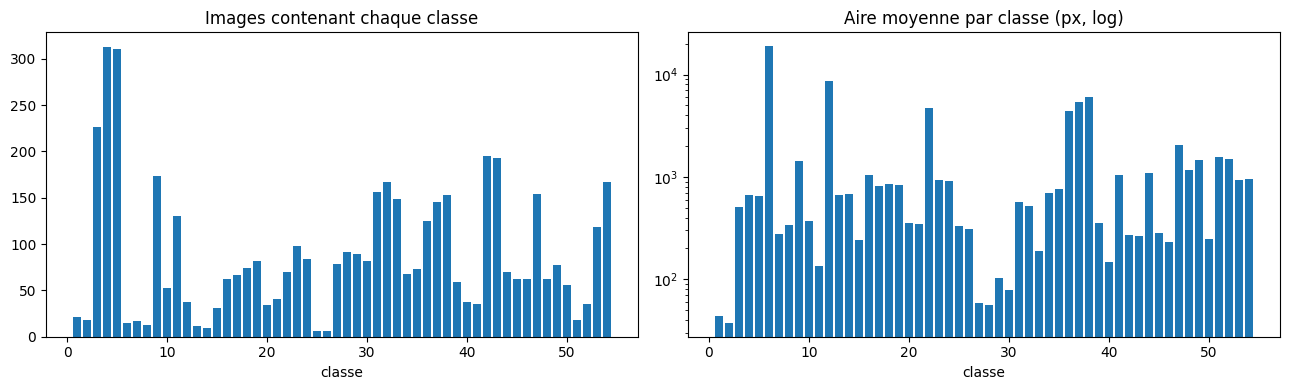


NUM_CLASSES retenu : 54


In [11]:
# Lancment du diagnostic

diag = run_diagnostic(data_train, Y_train, annotated_labels)

NUM_CLASSES = diag["NUM_CLASSES"]
print(f"\nNUM_CLASSES retenu : {NUM_CLASSES}")

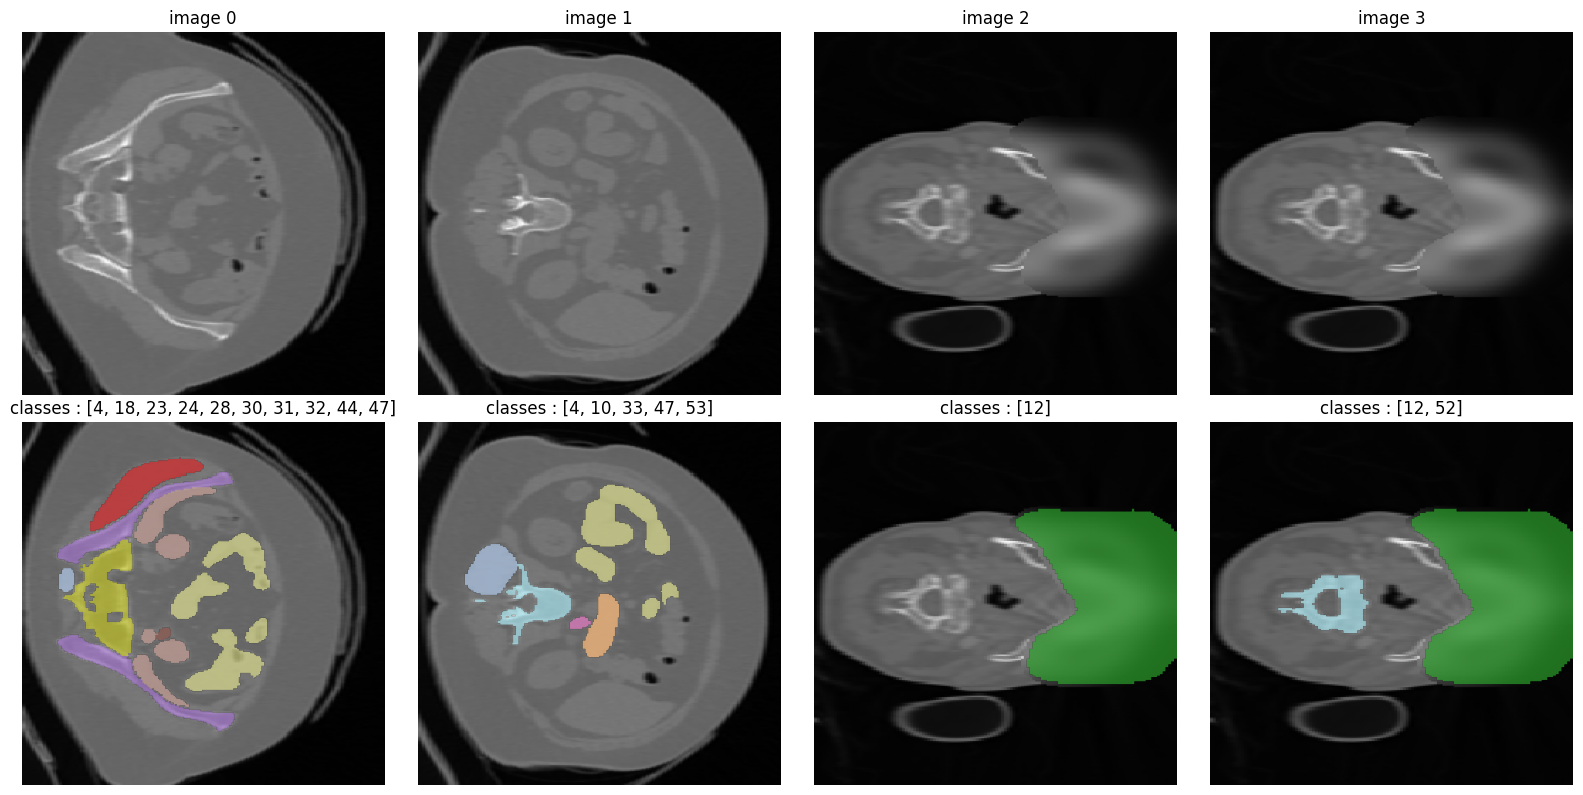

In [12]:
# Contrôle visuel image / masque sur 4 exemples annotés

idx = np.where(diag["has_ann"])[0][:4]
fig, axes = plt.subplots(2, len(idx), figsize=(4 * len(idx), 8))
for k, i in enumerate(idx):
    axes[0, k].imshow(data_train[i], cmap="gray")
    axes[0, k].set_title(f"image {i}")
    axes[0, k].axis("off")
    axes[1, k].imshow(data_train[i], cmap="gray")
    m = np.ma.masked_where(Y_train[i] == 0, Y_train[i])
    axes[1, k].imshow(m, cmap="tab20", alpha=0.7, vmin=0, vmax=NUM_CLASSES)
    axes[1, k].set_title(f"classes : {sorted(np.unique(Y_train[i])[1:].tolist())}")
    axes[1, k].axis("off")
plt.tight_layout()
plt.show()

In [16]:
# Statut de chaque couple (image, classe) via annotated_labels
# split par groupes de coupes quasi identiques pour éviter la fuite train/val.

import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components


def analyse_supervision(Y, annotated_labels, num_classes):
    N = len(Y)
    Yf = Y.reshape(N, -1)
    known = np.zeros((N, num_classes), dtype=bool)
    positive = np.zeros((N, num_classes), dtype=bool)

    for i in range(N):
        if isinstance(annotated_labels, dict):
            lst = annotated_labels.get(str(i), annotated_labels.get(i, []))
        else:
            lst = annotated_labels[i] if i < len(annotated_labels) else []
        for c in lst:
            if 1 <= c <= num_classes:
                known[i, c - 1] = True

    for i in range(N):
        for c in np.unique(Yf[i]):
            if c > 0:
                positive[i, c - 1] = True

    neg_certain = known & ~positive
    incoherent = positive & ~known

    print("=" * 66)
    print("SUPERVISION DISPONIBLE  (couples image x classe)")
    print("=" * 66)
    tot = N * num_classes
    print(f"  total                     : {tot:>9,}")
    print(f"  positifs (organe présent) : {positive.sum():>9,}  "
          f"{100*positive.sum()/tot:5.2f}%")
    print(f"  négatifs CERTAINS         : {neg_certain.sum():>9,}  "
          f"{100*neg_certain.sum()/tot:5.2f}%")
    print(f"  inconnus (à masquer)      : {(~known).sum():>9,}  "
          f"{100*(~known).sum()/tot:5.2f}%")
    if incoherent.sum():
        print(f"  INCOHÉRENTS (masque non listé) : {incoherent.sum()}")

    n_known_img = known.any(axis=1).sum()
    print(f"\n  images avec au moins une classe de statut certain : {n_known_img}")
    print("  >>> les négatifs certains sont une supervision GRATUITE :")
    print("      ils apprennent au modèle où un organe n'est PAS.")

    # supervision par classe
    print(f"\n  {'cls':>4} {'positifs':>9} {'nég.certains':>13} {'inconnus':>9}")
    for c in np.argsort(-positive.sum(axis=0))[:8]:
        print(f"  {c+1:>4} {positive[:,c].sum():>9} {neg_certain[:,c].sum():>13} "
              f"{(~known[:,c]).sum():>9}")
    print("  ...")
    for c in np.argsort(positive.sum(axis=0))[:4]:
        print(f"  {c+1:>4} {positive[:,c].sum():>9} {neg_certain[:,c].sum():>13} "
              f"{(~known[:,c]).sum():>9}")

    return {"known": known, "positive": positive, "neg_certain": neg_certain}


def detect_groups(X, thumb=16, seuil=None):

    N = len(X)
    d = np.stack([
        np.asarray(x, dtype=np.float32).reshape(thumb, X.shape[1] // thumb,
                                                thumb, X.shape[2] // thumb)
        .mean(axis=(1, 3)).ravel()
        for x in X
    ])
    d -= d.mean(axis=1, keepdims=True)
    n = np.linalg.norm(d, axis=1, keepdims=True)
    d /= np.maximum(n, 1e-8)
    sim = d @ d.T
    np.fill_diagonal(sim, -1)

    voisin = sim.max(axis=1)
    print("=" * 66)
    print("COUPES QUASI DUPLIQUÉES")
    print("=" * 66)
    for q in [50, 75, 90, 95, 99]:
        print(f"  similarité au plus proche voisin, p{q} : "
              f"{np.percentile(voisin, q):.4f}")

    if seuil is None:
        seuil = 0.98
    adj = csr_matrix(sim > seuil)
    n_groupes, groupe = connected_components(adj, directed=False)
    tailles = np.bincount(groupe)
    print(f"\n  seuil retenu : {seuil}")
    print(f"  {n_groupes} groupes pour {N} images")
    print(f"  taille de groupe : médiane={int(np.median(tailles))} "
          f"max={tailles.max()}")
    print(f"  images dans un groupe de taille > 1 : "
          f"{int((tailles[groupe] > 1).sum())}")
    return groupe


def split_groupe(groupe, mask_utilisable, val_frac=0.2, seed=42):
    """Split train/val en gardant chaque groupe entier d'un seul côté."""
    rng = np.random.default_rng(seed)
    idx = np.where(mask_utilisable)[0]
    g = np.unique(groupe[idx])
    g = rng.permutation(g)
    n_val = max(1, int(round(len(g) * val_frac)))
    g_val = set(g[:n_val].tolist())

    val = np.array([i for i in idx if groupe[i] in g_val])
    tr = np.array([i for i in idx if groupe[i] not in g_val])
    assert not (set(groupe[tr]) & set(groupe[val])), "fuite de groupe !"
    print(f"\n  train : {len(tr)} images   val : {len(val)} images")
    print("  aucun groupe partagé entre les deux.")
    return tr, val


sup = analyse_supervision(Y_train, annotated_labels, NUM_CLASSES)
print()
groupe = detect_groups(data_train)
annotees = sup["known"].any(axis=1) & (Y_train.reshape(len(Y_train), -1).max(axis=1) > 0)
idx_train, idx_val = split_groupe(groupe, annotees)

np.save(CACHE / "idx_train.npy", idx_train)
np.save(CACHE / "idx_val.npy", idx_val)
np.save(CACHE / "known.npy", sup["known"])
print("  splits et masques de supervision mis en cache.")

SUPERVISION DISPONIBLE  (couples image x classe)
  total                     :   108,000
  positifs (organe présent) :     4,781   4.43%
  négatifs CERTAINS         :    16,819  15.57%
  inconnus (à masquer)      :    86,400  80.00%

  images avec au moins une classe de statut certain : 800
  >>> les négatifs certains sont une supervision GRATUITE :
      ils apprennent au modèle où un organe n'est PAS.

   cls  positifs  nég.certains  inconnus
     4       313            93      1594
     5       311           104      1585
     3       226           176      1598
    42       195           195      1610
    43       193           201      1606
     9       173           219      1608
    32       167           233      1600
    54       167           237      1596
  ...
    25         6           409      1585
    26         6           387      1607
    14         9           382      1609
    13        12           418      1570

COUPES QUASI DUPLIQUÉES
  similarité au plus proche 

In [17]:
# Dataset, U-Net from scratch, loss masquée : 54 sigmoïdes indépendante ,
# gradient uniquement sur les couples (image, classe) de statut certain.

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# =====================================================================
class RaidiumDataset(Dataset):
    """Renvoie (image, cible, masque_de_statut).

    cible  : (54, H, W) binaire, 1 là où l'organe est présent
    masque : (54,) binaire, 1 si le statut de la classe est CERTAIN
    """

    def __init__(self, X, Y, known, indices, num_classes=54, augment=False):
        self.X, self.Y, self.known = X, Y, known
        self.idx = np.asarray(indices)
        self.K = num_classes
        self.augment = augment

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, j):
        i = self.idx[j]
        img = self.X[i].astype(np.float32) / 255.0
        lab = self.Y[i]

        if self.augment:
            if np.random.rand() < 0.5:
                img, lab = img[:, ::-1].copy(), lab[:, ::-1].copy()
            k = np.random.randint(4)
            if k:
                img, lab = np.rot90(img, k).copy(), np.rot90(lab, k).copy()
            if np.random.rand() < 0.3:
                img = np.clip(img * np.random.uniform(0.85, 1.15)
                              + np.random.uniform(-0.08, 0.08), 0, 1)

        cible = np.zeros((self.K, *lab.shape), dtype=np.float32)
        for c in np.unique(lab):
            if c > 0:
                cible[c - 1] = (lab == c)

        return (torch.from_numpy(img[None]),
                torch.from_numpy(cible),
                torch.from_numpy(self.known[i].astype(np.float32)))


# =====================================================================
class DoubleConv(nn.Module):
    def __init__(self, ci, co):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv2d(ci, co, 3, padding=1, bias=False),
            nn.BatchNorm2d(co), nn.ReLU(inplace=True),
            nn.Conv2d(co, co, 3, padding=1, bias=False),
            nn.BatchNorm2d(co), nn.ReLU(inplace=True))

    def forward(self, x):
        return self.f(x)


class UNet(nn.Module):
    """U-Net + tête de présence au niveau image."""

    def __init__(self, num_classes=54, base=32):
        super().__init__()
        b = base
        self.d1 = DoubleConv(1, b)
        self.d2 = DoubleConv(b, b * 2)
        self.d3 = DoubleConv(b * 2, b * 4)
        self.d4 = DoubleConv(b * 4, b * 8)
        self.bott = DoubleConv(b * 8, b * 16)
        self.pool = nn.MaxPool2d(2)

        self.u4 = nn.ConvTranspose2d(b * 16, b * 8, 2, 2)
        self.c4 = DoubleConv(b * 16, b * 8)
        self.u3 = nn.ConvTranspose2d(b * 8, b * 4, 2, 2)
        self.c3 = DoubleConv(b * 8, b * 4)
        self.u2 = nn.ConvTranspose2d(b * 4, b * 2, 2, 2)
        self.c2 = DoubleConv(b * 4, b * 2)
        self.u1 = nn.ConvTranspose2d(b * 2, b, 2, 2)
        self.c1 = DoubleConv(b * 2, b)

        self.seg = nn.Conv2d(b, num_classes, 1)
        self.presence = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(b * 16, num_classes))

    def forward(self, x):
        s1 = self.d1(x)
        s2 = self.d2(self.pool(s1))
        s3 = self.d3(self.pool(s2))
        s4 = self.d4(self.pool(s3))
        bo = self.bott(self.pool(s4))

        y = self.c4(torch.cat([self.u4(bo), s4], 1))
        y = self.c3(torch.cat([self.u3(y), s3], 1))
        y = self.c2(torch.cat([self.u2(y), s2], 1))
        y = self.c1(torch.cat([self.u1(y), s1], 1))
        return self.seg(y), self.presence(bo)


# =====================================================================
def masked_loss(logits, presence_logits, cible, masque,
                w_dice=1.0, w_bce=0.5, w_pres=0.3):
    """Loss sur les seuls couples (image, classe) de statut CERTAIN.

    logits  : (B, K, H, W)   masque : (B, K)   cible : (B, K, H, W)
    """
    B, K, H, W = logits.shape
    proba = torch.sigmoid(logits)

    aire = cible.sum(dim=(2, 3))                 # (B, K)
    positif = (aire > 0).float()
    m_pos = masque * positif                     # couples positifs connus

    # --- Dice doux, uniquement sur les positifs connus ---
    inter = (proba * cible).sum(dim=(2, 3))
    somme = proba.sum(dim=(2, 3)) + aire
    dice = (2 * inter + 1.0) / (somme + 1.0)
    l_dice = ((1 - dice) * m_pos).sum() / m_pos.sum().clamp(min=1)

    # --- BCE sur TOUS les couples connus (positifs ET négatifs certains) ---
    bce = F.binary_cross_entropy_with_logits(
        logits, cible, reduction="none").mean(dim=(2, 3))
    l_bce = (bce * masque).sum() / masque.sum().clamp(min=1)

    # --- Tête de présence, sur les couples connus ---
    pres = F.binary_cross_entropy_with_logits(
        presence_logits, positif, reduction="none")
    l_pres = (pres * masque).sum() / masque.sum().clamp(min=1)

    total = w_dice * l_dice + w_bce * l_bce + w_pres * l_pres
    return total, {"dice": l_dice.item(), "bce": l_bce.item(),
                   "pres": l_pres.item()}


# =====================================================================
@torch.no_grad()
def predire(model, X, indices, num_classes=54, seuil_pix=0.5,
            seuil_pres=0.5, batch=8):
    """Convertit les 54 sigmoïdes en une carte de labels unique.

    Règle : la tête de présence éteint les classes jugées absentes
    (les faux positifs sont pénalisés par la métrique), puis argmax
    sur les classes restantes au-dessus du seuil pixel.
    """
    model.eval()
    out = np.zeros((len(indices), X.shape[1], X.shape[2]), dtype=np.uint8)
    for s in range(0, len(indices), batch):
        sel = indices[s:s + batch]
        x = torch.from_numpy(X[sel].astype(np.float32) / 255.0)[:, None].to(DEVICE)
        seg, pres = model(x)
        p = torch.sigmoid(seg)
        garde = (torch.sigmoid(pres) > seuil_pres).float()[:, :, None, None]
        p = p * garde
        val, arg = p.max(dim=1)
        lab = torch.where(val > seuil_pix, arg + 1, torch.zeros_like(arg))
        out[s:s + batch] = lab.cpu().numpy().astype(np.uint8)
    return out

In [18]:
# Entraînement, évaluation, calibration des seuils

import time

import numpy as np
import torch
from torch.utils.data import DataLoader


def classes_connues(known, indices):
    """Convertit le masque booléen en listes d'IDs, pour dice_score."""
    return [np.nonzero(known[i])[0] + 1 for i in indices]


@torch.no_grad()
def evaluer(model, X, Y, known, indices, num_classes,
            seuil_pix=0.5, seuil_pres=0.5):
    """Score sur la métrique OFFICIELLE, en masquant les classes non annotées.

    Sans ce masquage, un organe correctement segmenté mais non annoté
    serait compté comme faux positif : le score local serait pessimiste
    et décorrélé du leaderboard, où le test est intégralement annoté.
    """
    pred = predire(model, X, indices, num_classes, seuil_pix, seuil_pres)
    return dice_score(pred, Y[indices], num_classes,
                      annotated_per_image=classes_connues(known, indices))


def entrainer(model, X, Y, known, idx_train, idx_val, num_classes,
              epochs=60, batch=8, lr=3e-4, eval_tous=5,
              nom="unet_v1", reprendre=True):

    ckpt = CACHE / f"{nom}.pt"
    ds_tr = RaidiumDataset(X, Y, known, idx_train, num_classes, augment=True)
    dl_tr = DataLoader(ds_tr, batch_size=batch, shuffle=True,
                       num_workers=2, drop_last=True, pin_memory=True)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.amp.GradScaler(DEVICE) if DEVICE == "cuda" else None

    ep0, meilleur, histo = 0, -1.0, []
    if reprendre and ckpt.exists():
        st = torch.load(ckpt, map_location=DEVICE)
        model.load_state_dict(st["model"])
        opt.load_state_dict(st["opt"])
        sched.load_state_dict(st["sched"])
        ep0, meilleur, histo = st["epoch"] + 1, st["meilleur"], st["histo"]
        print(f"Reprise à l'epoch {ep0} (meilleur score : {meilleur:.4f})")

    for ep in range(ep0, epochs):
        model.train()
        t0, cum, n = time.time(), 0.0, 0
        for x, c, m in dl_tr:
            x, c, m = x.to(DEVICE), c.to(DEVICE), m.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            if scaler:
                with torch.amp.autocast(DEVICE):
                    seg, pres = model(x)
                    loss, parts = masked_loss(seg, pres, c, m)
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            else:
                seg, pres = model(x)
                loss, parts = masked_loss(seg, pres, c, m)
                loss.backward()
                opt.step()
            cum += loss.item()
            n += 1
        sched.step()

        ligne = f"ep {ep:>3}  loss {cum/max(n,1):.4f}  {time.time()-t0:5.1f}s"
        if (ep + 1) % eval_tous == 0 or ep == epochs - 1:
            sc = evaluer(model, X, Y, known, idx_val, num_classes)
            histo.append((ep, sc))
            ligne += f"  |  DICE val {sc:.4f}"
            if sc > meilleur:
                meilleur = sc
                torch.save({"model": model.state_dict()},
                           CACHE / f"{nom}_best.pt")
                ligne += "  <- meilleur"
        print(ligne)

        torch.save({"model": model.state_dict(), "opt": opt.state_dict(),
                    "sched": sched.state_dict(), "epoch": ep,
                    "meilleur": meilleur, "histo": histo}, ckpt)

    print(f"\nMeilleur DICE validation : {meilleur:.4f}")
    return meilleur, histo


def calibrer_seuils(model, X, Y, known, idx_val, num_classes,
                    pix=(0.3, 0.4, 0.5, 0.6), pres=(0.2, 0.3, 0.5, 0.7)):
    """Cherche le couple de seuils qui maximise la métrique officielle.

    Vaut souvent 1 à 3 points de DICE sans réentraîner quoi que ce soit :
    la métrique pénalise les faux positifs sur les classes absentes, donc
    le seuil de présence n'a aucune raison d'être à 0.5 par défaut.
    """
    best = (None, -1.0)
    print(f"  {'pix':>5} {'pres':>6} {'dice':>8}")
    for sp in pix:
        for sr in pres:
            sc = evaluer(model, X, Y, known, idx_val, num_classes, sp, sr)
            print(f"  {sp:>5.2f} {sr:>6.2f} {sc:>8.4f}"
                  + ("  <-" if sc > best[1] else ""))
            if sc > best[1]:
                best = ((sp, sr), sc)
    print(f"\nMeilleur : seuil_pix={best[0][0]}  seuil_pres={best[0][1]}  "
          f"-> {best[1]:.4f}")
    return best


def rapport_par_classe(model, X, Y, known, idx_val, num_classes,
                       seuil_pix=0.5, seuil_pres=0.5):
    """DICE par classe AVEC le nombre de positifs en validation.

    Une classe avec 1 ou 2 positifs en validation donne un chiffre non
    fiable : ne prends aucune décision dessus.
    """
    pred = predire(model, X, idx_val, num_classes, seuil_pix, seuil_pres)
    m = dice_matrix(pred, Y[idx_val], num_classes)
    keep = np.zeros_like(m, dtype=bool)
    for k, i in enumerate(idx_val):
        keep[k, np.nonzero(known[i])[0]] = True
    m = np.where(keep, m, np.nan)

    Yv = Y[idx_val].reshape(len(idx_val), -1)
    print(f"  {'cls':>4} {'n_pos_val':>10} {'dice':>8}")
    lignes = []
    for c in range(1, num_classes + 1):
        npos = int((Yv == c).any(axis=1).sum())
        with np.errstate(invalid="ignore"):
            d = np.nanmean(m[:, c - 1]) if not np.all(np.isnan(m[:, c - 1])) else np.nan
        lignes.append((c, npos, d))
    for c, npos, d in sorted(lignes, key=lambda t: -(t[2] if t[2] == t[2] else -1)):
        flag = "  (peu fiable)" if npos < 3 else ""
        print(f"  {c:>4} {npos:>10} {d:>8.4f}{flag}")
    return lignes


# =====================================================================
# LANCEMENT
# =====================================================================
known = np.load(CACHE / "known.npy")
idx_train = np.load(CACHE / "idx_train.npy")
idx_val = np.load(CACHE / "idx_val.npy")

torch.manual_seed(0)
model = UNet(NUM_CLASSES, base=32).to(DEVICE)
print(f"device={DEVICE}  paramètres="
      f"{sum(p.numel() for p in model.parameters())/1e6:.1f} M")
print(f"train={len(idx_train)}  val={len(idx_val)}\n")

meilleur, histo = entrainer(model, data_train, Y_train, known,
                            idx_train, idx_val, NUM_CLASSES,
                            epochs=60, batch=8, eval_tous=5)

device=cuda  paramètres=7.8 M
train=610  val=149

ep   0  loss 1.4289   14.5s
ep   1  loss 1.3281   12.3s
ep   2  loss 1.2462   11.7s
ep   3  loss 1.1883   11.5s


/tmp/ipykernel_750/830813322.py:39: RuntimeWarning: Mean of empty slice
  return float(np.nanmean(np.nanmean(m, axis=0)))


ep   4  loss 1.1411   12.6s  |  DICE val 0.0226  <- meilleur
ep   5  loss 1.1087   13.6s
ep   6  loss 1.0749   14.0s
ep   7  loss 1.0510   13.9s
ep   8  loss 1.0263   12.6s
ep   9  loss 0.9954   13.1s  |  DICE val 0.0548  <- meilleur
ep  10  loss 0.9713   12.9s
ep  11  loss 0.9405   12.9s
ep  12  loss 0.9143   12.9s
ep  13  loss 0.8933   12.7s
ep  14  loss 0.8700   12.6s  |  DICE val 0.0571  <- meilleur
ep  15  loss 0.8477   12.9s
ep  16  loss 0.8314   13.0s
ep  17  loss 0.8235   12.9s
ep  18  loss 0.8076   12.6s
ep  19  loss 0.7852   13.4s  |  DICE val 0.1103  <- meilleur
ep  20  loss 0.7801   13.6s
ep  21  loss 0.7666   12.3s
ep  22  loss 0.7577   13.4s
ep  23  loss 0.7497   11.2s
ep  24  loss 0.7414   11.9s  |  DICE val 0.1190  <- meilleur
ep  25  loss 0.7350   13.6s
ep  26  loss 0.7243   13.9s
ep  27  loss 0.7237   12.9s
ep  28  loss 0.7136   13.0s
ep  29  loss 0.7098   13.1s  |  DICE val 0.1591  <- meilleur
ep  30  loss 0.7065   13.4s
ep  31  loss 0.6965   13.4s
ep  32  loss 0.691

In [20]:
# Calibration des seuils et DICE par classe sur la v1.
best = calibrer_seuils(model, data_train, Y_train, known, idx_val, NUM_CLASSES)
lignes = rapport_par_classe(model, data_train, Y_train, known, idx_val, NUM_CLASSES,
                            seuil_pix=best[0][0], seuil_pres=best[0][1])

    pix   pres     dice
   0.30   0.20   0.1674  <-
   0.30   0.30   0.1814  <-
   0.30   0.50   0.2030  <-
   0.30   0.70   0.1884
   0.40   0.20   0.1652
   0.40   0.30   0.1790
   0.40   0.50   0.2007
   0.40   0.70   0.1859
   0.50   0.20   0.1629
   0.50   0.30   0.1764
   0.50   0.50   0.1980
   0.50   0.70   0.1830
   0.60   0.20   0.1604
   0.60   0.30   0.1730
   0.60   0.50   0.1943
   0.60   0.70   0.1791

Meilleur : seuil_pix=0.3  seuil_pres=0.5  -> 0.2030
   cls  n_pos_val     dice
    12          3   0.8232
     6          5   0.7363
    38         32   0.7224
    54         33   0.6920
    50         11   0.6295
    36         26   0.6197
     3         44   0.5616
     9         29   0.5242
    53         21   0.4980
    52          7   0.4975
    22         16   0.4750
    42         40   0.4642
    47         29   0.4155
    45         13   0.3688
     4         61   0.3530
    32         33   0.3467
    44         14   0.2803
    31         24   0.2677
     5        

In [22]:
# Détection des paires gauche/droite, centre du corps mesuré image par image.
# Une seule paire crédible en sortie(miroir laissé désactivé)

import numpy as np

def analyser_lateralite(X, Y, known, num_classes, size=256, top=18):
    N = len(Y)
    Yf = Y.reshape(N, -1).astype(np.int64)
    yy, xx = np.mgrid[0:size, 0:size]
    yflat, xflat = yy.ravel().astype(float), xx.ravel().astype(float)

    # --- centre du corps, image par image ---
    seuil_corps = max(10, int(np.percentile(X[:50], 60)))
    cx0 = np.zeros(N)
    cy0 = np.zeros(N)
    for i in range(N):
        m = X[i] > seuil_corps
        if m.sum() < 100:
            cx0[i], cy0[i] = (size - 1) / 2, (size - 1) / 2
        else:
            cx0[i], cy0[i] = xx[m].mean(), yy[m].mean()

    # --- décalage signé de chaque classe par rapport au centre du corps ---
    dx = [[] for _ in range(num_classes + 1)]
    dy = [[] for _ in range(num_classes + 1)]
    aire = [[] for _ in range(num_classes + 1)]
    presence = np.zeros((N, num_classes + 1), dtype=bool)

    for i in range(N):
        n = np.bincount(Yf[i], minlength=num_classes + 1)[:num_classes + 1]
        sy = np.bincount(Yf[i], weights=yflat, minlength=num_classes + 1)[:num_classes + 1]
        sx = np.bincount(Yf[i], weights=xflat, minlength=num_classes + 1)[:num_classes + 1]
        presence[i] = n > 0
        for c in np.nonzero(n[1:])[0] + 1:
            dx[c].append(sx[c] / n[c] - cx0[i])
            dy[c].append(sy[c] / n[c] - cy0[i])
            aire[c].append(n[c])

    mdx = np.array([np.mean(v) if v else np.nan for v in dx])
    mdy = np.array([np.mean(v) if v else np.nan for v in dy])
    mar = np.array([np.mean(v) if v else np.nan for v in aire])
    nimg = presence.sum(axis=0)

    print("=" * 70)
    print("LATÉRALITÉ PAR CLASSE  (décalage x par rapport au centre du corps)")
    print("=" * 70)
    print(f"  {'cls':>4} {'dx':>8} {'dy':>8} {'aire':>8} {'n_img':>6}  côté")
    for c in np.argsort(mdx[1:]) + 1:
        if np.isnan(mdx[c]):
            continue
        cote = "GAUCHE" if mdx[c] < -12 else ("DROITE" if mdx[c] > 12 else "médian")
        print(f"  {c:>4} {mdx[c]:>8.1f} {mdy[c]:>8.1f} {mar[c]:>8.0f} "
              f"{int(nimg[c]):>6}  {cote}")

    lat = np.abs(mdx) > 12
    print(f"\n  latéralisées : {int(np.nansum(lat[1:]))} / {num_classes}")
    print(f"  médianes     : {int(np.sum(~lat[1:] & ~np.isnan(mdx[1:])))}")

    # --- candidats paires ---
    print()
    print("=" * 70)
    print(f"CANDIDATS PAIRES — {top} meilleurs, seuil ou pas")
    print("=" * 70)
    cands = []
    for a in range(1, num_classes + 1):
        for b in range(a + 1, num_classes + 1):
            if np.isnan(mdx[a]) or np.isnan(mdx[b]):
                continue
            if mdx[a] * mdx[b] >= 0:       # doivent être de part et d'autre
                continue
            # co-occurrence conditionnée aux images où les DEUX sont annotées
            both = known[:, a - 1] & known[:, b - 1]
            if both.sum() < 5:
                continue
            pa = presence[both, a]
            pb = presence[both, b]
            inter = (pa & pb).sum()
            union = (pa | pb).sum()
            cooc = inter / max(union, 1)

            sym = abs(mdx[a] + mdx[b]) / max(abs(mdx[a]), abs(mdx[b]))
            haut = abs(mdy[a] - mdy[b]) / size
            tail = abs(np.log((mar[a] + 1) / (mar[b] + 1)))
            cout = 2 * sym + 3 * haut + 0.5 * tail + 1.5 * (1 - cooc)
            cands.append((cout, a, b, sym, haut, tail, cooc))

    cands.sort()
    print(f"  {'a':>3} {'b':>4} {'coût':>7} {'asym':>7} {'Δy':>6} "
          f"{'Δlog(aire)':>11} {'cooc':>6} {'aire_a':>8} {'aire_b':>8}")
    for cout, a, b, sym, haut, tail, cooc in cands[:top]:
        print(f"  {a:>3} {b:>4} {cout:>7.3f} {sym:>7.2f} {haut*size:>6.1f} "
              f"{tail:>11.2f} {cooc:>6.2f} {mar[a]:>8.0f} {mar[b]:>8.0f}")

    print("\n  Lecture : asym proche de 0 = décalages opposés et de même")
    print("  amplitude ; cooc proche de 1 = les deux apparaissent ensemble.")
    print("  Une vraie paire gauche/droite a asym<0.3, Δy<15, cooc>0.6.")
    return {"mdx": mdx, "mdy": mdy, "aire": mar, "nimg": nimg,
            "cands": cands, "presence": presence}


def paires_depuis_candidats(cands, cout_max=1.2, asym_max=0.35,
                            cooc_min=0.55, num_classes=54):
    """Retient les candidats crédibles, chaque classe une seule fois."""
    paires, vus = {}, set()
    for cout, a, b, sym, haut, tail, cooc in cands:
        if cout > cout_max or sym > asym_max or cooc < cooc_min:
            continue
        if a in vus or b in vus:
            continue
        paires[a], paires[b] = b, a
        vus |= {a, b}
    lut = np.arange(num_classes + 1, dtype=np.uint8)
    for a, b in paires.items():
        lut[a] = b
    print(f"\n  {len(paires)//2} paires retenues : "
          f"{sorted((a, b) for a, b in paires.items() if a < b)}")
    return paires, lut


# =====================================================================
info = analyser_lateralite(data_train, Y_train, known, NUM_CLASSES)
paires, LUT = paires_depuis_candidats(info["cands"], num_classes=NUM_CLASSES)
np.save(CACHE / "lut_paires.npy", LUT)
print("  involution vérifiée :",
      bool((LUT[LUT] == np.arange(NUM_CLASSES + 1)).all()))

LATÉRALITÉ PAR CLASSE  (décalage x par rapport au centre du corps)
   cls       dx       dy     aire  n_img  côté
     4    -57.6    -20.3      666    313  GAUCHE
     5    -55.3     22.2      647    311  GAUCHE
    16    -43.7    -58.1     1051     62  GAUCHE
    17    -42.2     62.2      821     67  GAUCHE
    54    -40.0      4.9      952    167  GAUCHE
    45    -37.9    -92.7      285     62  GAUCHE
    44    -37.6     -0.4     1093     70  GAUCHE
    46    -30.1     96.9      230     62  GAUCHE
    53    -20.3      0.1      940    118  GAUCHE
    48    -19.0    -63.5     1169     62  GAUCHE
    18    -15.8    -71.5      858     74  GAUCHE
    34    -15.0    -46.8      697     68  GAUCHE
    43    -14.6     74.9      264    193  GAUCHE
    35    -12.3     47.5      760     73  GAUCHE
     6    -11.9      0.0    18931     15  médian
    37    -11.7    -54.1     5387    145  médian
    23    -11.2    -51.9      922     98  médian
     2     -9.9     18.2       37     18  médian
    

In [24]:
!pip install -q segmentation-models-pytorch

# encodeur ResNet34 ImageNet (seules les sources radiologiques sont interdites)
# Aucune rotation 90 , miroir off, 250 epochs, seuil pixel 0.30

import time
import warnings

import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore", message="Mean of empty slice")
import segmentation_models_pytorch as smp

# --- garde-fou : échouer bruyamment plutôt que silencieusement --------
for _v in ["data_train", "Y_train", "NUM_CLASSES", "CACHE", "known",
           "idx_train", "idx_val", "DEVICE", "masked_loss", "dice_score"]:
    if _v not in dir():
        raise NameError(
            f"`{_v}` est introuvable : relance les cellules 4, 5, 9 et 10 "
            "avant celle-ci (une session Colab redémarrée perd tout)."
        )

UTILISER_MIROIR = False
LUT = np.load(CACHE / "lut_paires.npy") if UTILISER_MIROIR else None
print(f"miroir : {'ACTIVÉ' if UTILISER_MIROIR else 'désactivé'}")


# =====================================================================
class RaidiumDatasetV2(Dataset):
    """Augmentation respectant l'anatomie d'une coupe axiale."""

    def __init__(self, X, Y, known, indices, lut=None, num_classes=54,
                 augment=False, p_flip=0.5, axe_flip=1, max_rot=15,
                 max_scale=0.12, max_shift=0.06):
        self.X, self.Y, self.known = X, Y, known
        self.idx = np.asarray(indices)
        self.K, self.augment, self.lut = num_classes, augment, lut
        self.p_flip = p_flip if lut is not None else 0.0
        self.axe_flip = axe_flip          # 1 = horizontal, 0 = vertical
        self.max_rot, self.max_scale, self.max_shift = max_rot, max_scale, max_shift

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, j):
        i = self.idx[j]
        img = self.X[i].astype(np.float32) / 255.0
        lab = self.Y[i].copy()

        if self.augment:
            if np.random.rand() < self.p_flip:
                img = np.flip(img, axis=self.axe_flip).copy()
                lab = self.lut[np.flip(lab, axis=self.axe_flip)].copy()

            if np.random.rand() < 0.8:
                h, w = img.shape
                M = cv2.getRotationMatrix2D(
                    (w / 2, h / 2),
                    np.random.uniform(-self.max_rot, self.max_rot),
                    1.0 + np.random.uniform(-self.max_scale, self.max_scale))
                M[0, 2] += np.random.uniform(-self.max_shift, self.max_shift) * w
                M[1, 2] += np.random.uniform(-self.max_shift, self.max_shift) * h
                img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR,
                                     borderValue=0.0)
                lab = cv2.warpAffine(lab, M, (w, h), flags=cv2.INTER_NEAREST,
                                     borderValue=0)

            if np.random.rand() < 0.4:
                img = np.clip(img * np.random.uniform(0.88, 1.12)
                              + np.random.uniform(-0.06, 0.06), 0, 1)

        cible = np.zeros((self.K, *lab.shape), dtype=np.float32)
        for c in np.unique(lab):
            if c > 0:
                cible[c - 1] = (lab == c)
        return (torch.from_numpy(np.ascontiguousarray(img)[None]),
                torch.from_numpy(cible),
                torch.from_numpy(self.known[i].astype(np.float32)))


# =====================================================================
class UNetPretrained(nn.Module):
    def __init__(self, num_classes=54, encoder="resnet34", weights="imagenet"):
        super().__init__()
        self.net = smp.Unet(encoder_name=encoder, encoder_weights=weights,
                            in_channels=3, classes=num_classes,
                            aux_params=dict(classes=num_classes, dropout=0.2))

    def forward(self, x):
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        return self.net(x)

    def groupes_params(self, lr_enc=1e-4, lr_dec=3e-4):
        enc = list(self.net.encoder.parameters())
        ids = {id(p) for p in enc}
        autres = [p for p in self.parameters() if id(p) not in ids]
        return [{"params": enc, "lr": lr_enc}, {"params": autres, "lr": lr_dec}]


# =====================================================================
def classes_connues(known, indices):
    return [np.nonzero(known[i])[0] + 1 for i in indices]


@torch.no_grad()
def predire_tta(model, X, indices, num_classes=54, seuil_pix=0.30,
                seuil_pres=0.50, batch=8, lut=None, axe_flip=1, n_tta=1):
    model.eval()
    out = np.zeros((len(indices), X.shape[1], X.shape[2]), dtype=np.uint8)
    perm = None
    if lut is not None and n_tta >= 2:
        perm = torch.as_tensor(lut[1:num_classes + 1].astype(np.int64) - 1,
                               device=DEVICE)
    dim = 3 if axe_flip == 1 else 2
    for s in range(0, len(indices), batch):
        sel = indices[s:s + batch]
        x0 = torch.from_numpy(X[sel].astype(np.float32) / 255.0)[:, None].to(DEVICE)
        seg, pres = model(x0)
        p, r, n = torch.sigmoid(seg), torch.sigmoid(pres), 1
        if perm is not None:
            seg2, pres2 = model(torch.flip(x0, dims=[dim]))
            p = p + torch.flip(torch.sigmoid(seg2), dims=[dim])[:, perm]
            r = r + torch.sigmoid(pres2)[:, perm]
            n = 2
        p, r = p / n, r / n
        p = p * (r > seuil_pres).float()[:, :, None, None]
        val, arg = p.max(dim=1)
        out[s:s + batch] = torch.where(
            val > seuil_pix, arg + 1,
            torch.zeros_like(arg)).cpu().numpy().astype(np.uint8)
    return out


# =====================================================================
# ENTRAÎNEMENT
# =====================================================================
EPOCHS, NOM = 250, "unet_r34_v2"
torch.manual_seed(0)
model2 = UNetPretrained(NUM_CLASSES, encoder="resnet34").to(DEVICE)
print(f"device={DEVICE}   paramètres="
      f"{sum(p.numel() for p in model2.parameters())/1e6:.1f} M")
print(f"train={len(idx_train)}   val={len(idx_val)}\n")

ds_tr = RaidiumDatasetV2(data_train, Y_train, known, idx_train, lut=LUT,
                         num_classes=NUM_CLASSES, augment=True)
dl_tr = DataLoader(ds_tr, batch_size=8, shuffle=True, num_workers=2,
                   drop_last=True, pin_memory=True)

opt = torch.optim.AdamW(model2.groupes_params(1e-4, 3e-4), weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
scaler = torch.amp.GradScaler(DEVICE) if DEVICE == "cuda" else None

ckpt = CACHE / f"{NOM}.pt"
ep0, meilleur, histo = 0, -1.0, []
if ckpt.exists():
    st = torch.load(ckpt, map_location=DEVICE, weights_only=False)
    model2.load_state_dict(st["model"]); opt.load_state_dict(st["opt"])
    sched.load_state_dict(st["sched"])
    ep0, meilleur, histo = st["epoch"] + 1, st["meilleur"], st["histo"]
    print(f"Reprise à l'epoch {ep0} (meilleur {meilleur:.4f})")

for ep in range(ep0, EPOCHS):
    model2.train()
    t0, cum, n = time.time(), 0.0, 0
    for x, c, m in dl_tr:
        x, c, m = x.to(DEVICE), c.to(DEVICE), m.to(DEVICE)
        opt.zero_grad(set_to_none=True)
        if scaler:
            with torch.amp.autocast(DEVICE):
                seg, pres = model2(x)
                loss, _ = masked_loss(seg, pres, c, m)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        else:
            seg, pres = model2(x)
            loss, _ = masked_loss(seg, pres, c, m)
            loss.backward(); opt.step()
        cum += loss.item(); n += 1
    sched.step()

    ligne = f"ep {ep:>3}  loss {cum/max(n,1):.4f}  {time.time()-t0:5.1f}s"
    if (ep + 1) % 10 == 0 or ep == EPOCHS - 1:
        pred = predire_tta(model2, data_train, idx_val, NUM_CLASSES, 0.30, 0.50)
        sc = dice_score(pred, Y_train[idx_val], NUM_CLASSES,
                        annotated_per_image=classes_connues(known, idx_val))
        histo.append((ep, sc))
        ligne += f"  |  DICE val {sc:.4f}"
        if sc > meilleur:
            meilleur = sc
            torch.save({"model": model2.state_dict()}, CACHE / f"{NOM}_best.pt")
            ligne += "  <- meilleur"
    print(ligne)
    torch.save({"model": model2.state_dict(), "opt": opt.state_dict(),
                "sched": sched.state_dict(), "epoch": ep,
                "meilleur": meilleur, "histo": histo}, ckpt)

print(f"\nMeilleur DICE validation : {meilleur:.4f}   (référence : 0.1980)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.6 MB/s eta 0:00:00
miroir : désactivé


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

device=cuda   paramètres=24.5 M
train=610   val=149

ep   0  loss 1.3213   13.4s
ep   1  loss 1.0766   13.1s
ep   2  loss 0.9770   12.9s
ep   3  loss 0.8746   12.8s
ep   4  loss 0.7845   13.3s
ep   5  loss 0.7021   13.2s
ep   6  loss 0.6459   14.1s
ep   7  loss 0.5999   13.7s
ep   8  loss 0.5369   13.8s
ep   9  loss 0.5045   13.6s  |  DICE val 0.3464  <- meilleur
ep  10  loss 0.4814   13.7s
ep  11  loss 0.4579   13.5s
ep  12  loss 0.4337   14.2s
ep  13  loss 0.4112   13.6s
ep  14  loss 0.3808   13.8s
ep  15  loss 0.3625   13.5s
ep  16  loss 0.3412   14.2s
ep  17  loss 0.3228   13.5s
ep  18  loss 0.3128   14.1s
ep  19  loss 0.2966   13.7s  |  DICE val 0.4922  <- meilleur
ep  20  loss 0.2851   13.4s
ep  21  loss 0.2776   13.3s
ep  22  loss 0.2696   14.2s
ep  23  loss 0.2550   13.6s
ep  24  loss 0.2488   15.4s
ep  25  loss 0.2433   13.2s
ep  26  loss 0.2370   14.4s
ep  27  loss 0.2289   13.7s
ep  28  loss 0.2300   13.6s
ep  29  loss 0.2249   13.9s  |  DICE val 0.5261  <- meilleur
ep  30  

In [25]:
# Encadrement du score : borne haute = classes non annotées masquées
# borne basse = tout compté ( Le leaderboard tombe entre les deux ) .

import numpy as np
import pandas as pd
import torch


def encadrer(model, X, Y, known, idx_val, num_classes,
             seuil_pix=0.30, seuil_pres=0.50):
    pred = predire_tta(model, X, idx_val, num_classes, seuil_pix, seuil_pres)
    haut = dice_score(pred, Y[idx_val], num_classes,
                      annotated_per_image=classes_connues(known, idx_val))
    bas = dice_score(pred, Y[idx_val], num_classes)
    return bas, haut


def calibrer(model, X, Y, known, idx_val, num_classes,
             pix=(0.15, 0.25, 0.35, 0.45), pres=(0.35, 0.50, 0.65, 0.80)):
    """Optimise sur la borne BASSE : c'est elle qui pénalise les faux
    positifs, comme le fera le jeu de test intégralement annoté."""
    print(f"  {'pix':>5} {'pres':>6} {'bas':>8} {'haut':>8}")
    best = (None, -1.0, -1.0)
    for sp in pix:
        for sr in pres:
            bas, haut = encadrer(model, X, Y, known, idx_val,
                                 num_classes, sp, sr)
            marque = ""
            if bas > best[1]:
                best, marque = ((sp, sr), bas, haut), "  <-"
            print(f"  {sp:>5.2f} {sr:>6.2f} {bas:>8.4f} {haut:>8.4f}{marque}")
    print(f"\n  retenu : pix={best[0][0]}  pres={best[0][1]}")
    print(f"  score réel attendu entre {best[1]:.4f} et {best[2]:.4f}")
    return best[0]


def generer_soumission(model, X_test, num_classes, seuil_pix, seuil_pres,
                       chemin, Y_ref=None, batch=8):
    """Écrit le CSV au format attendu : transposée de la matrice aplatie."""
    idx = np.arange(len(X_test))
    pred = predire_tta(model, X_test, idx, num_classes, seuil_pix,
                       seuil_pres, batch=batch)

    # --- contrôles avant écriture -----------------------------------
    print("=" * 60)
    print("CONTRÔLES")
    print("=" * 60)
    print(f"  forme            : {pred.shape}  dtype={pred.dtype}")
    print(f"  valeurs          : min={pred.min()} max={pred.max()}")
    assert pred.shape == (len(X_test), 256, 256), "forme inattendue"
    assert pred.max() <= num_classes, "label hors intervalle"

    pf = pred.reshape(len(pred), -1)
    n_cls = np.array([len(np.unique(r)) - (1 if (r == 0).any() else 0)
                      for r in pf])
    frac = (pf > 0).mean()
    print(f"  classes par image : moyenne={n_cls.mean():.1f} "
          f"médiane={np.median(n_cls):.0f} min={n_cls.min()} max={n_cls.max()}")
    print(f"  images sans aucune prédiction : {(n_cls == 0).sum()}")
    print(f"  fraction de pixels segmentés  : {frac:.3f}")

    if Y_ref is not None:
        rf = Y_ref.reshape(len(Y_ref), -1)
        garde = rf.max(axis=1) > 0
        n_ref = np.array([len(np.unique(r)) - 1 for r in rf[garde]])
        print(f"\n  référence train (annotée, 27 classes connues sur 54) :")
        print(f"    classes par image : moyenne={n_ref.mean():.1f}")
        print(f"    fraction segmentée : {(rf[garde] > 0).mean():.3f}")
        print("  Le test est INTÉGRALEMENT annoté : il est normal que le")
        print("  modèle prédise plus de classes par image que le train.")

    # --- écriture ----------------------------------------------------
    pd.DataFrame(pf).T.to_csv(chemin)
    verif = pd.read_csv(chemin, index_col=0).T.values.reshape((-1, 256, 256))
    assert np.array_equal(verif.astype(np.uint8), pred), \
        "l'aller-retour CSV ne redonne pas les prédictions !"
    print(f"\n  écrit et relu sans perte : {chemin}")
    return pred


# =====================================================================
# EXÉCUTION
# =====================================================================
model2.load_state_dict(
    torch.load(CACHE / "unet_r34_v2_best.pt", map_location=DEVICE)["model"])
print("meilleur modèle rechargé\n")

bas, haut = encadrer(model2, data_train, Y_train, known, idx_val, NUM_CLASSES)
print(f"Avec les seuils actuels : borne basse {bas:.4f}, borne haute {haut:.4f}")
print(f"Benchmark nnU-Net à battre : 0.4399\n")

print("CALIBRATION")
sp, sr = calibrer(model2, data_train, Y_train, known, idx_val, NUM_CLASSES)

print()
pred_test = generer_soumission(model2, data_test, NUM_CLASSES, sp, sr,
                               chemin=str(CACHE / "soumission_r34_v2.csv"),
                               Y_ref=Y_train)

meilleur modèle rechargé

Avec les seuils actuels : borne basse 0.3513, borne haute 0.6338
Benchmark nnU-Net à battre : 0.4399

CALIBRATION
    pix   pres      bas     haut
   0.15   0.35   0.3513   0.6376  <-
   0.15   0.50   0.3529   0.6362  <-
   0.15   0.65   0.3537   0.6341  <-
   0.15   0.80   0.3555   0.6294  <-
   0.25   0.35   0.3504   0.6365
   0.25   0.50   0.3521   0.6351
   0.25   0.65   0.3529   0.6329
   0.25   0.80   0.3545   0.6282
   0.35   0.35   0.3491   0.6341
   0.35   0.50   0.3508   0.6328
   0.35   0.65   0.3516   0.6307
   0.35   0.80   0.3532   0.6261
   0.45   0.35   0.3488   0.6321
   0.45   0.50   0.3506   0.6309
   0.45   0.65   0.3514   0.6284
   0.45   0.80   0.3531   0.6238

  retenu : pix=0.15  pres=0.8
  score réel attendu entre 0.3555 et 0.6294

CONTRÔLES
  forme            : (500, 256, 256)  dtype=uint8
  valeurs          : min=0 max=54
  classes par image : moyenne=10.3 médiane=11 min=0 max=20
  images sans aucune prédiction : 4
  fraction de pixe

In [28]:
## Grille de seuils étendue (l'optimum précédent tombait sur un bord) et rattrapage
# des images restées vides, qui valaient 0 sur toutes leurs classes

import numpy as np
import pandas as pd
import torch


def rattraper_vides(model, X_test, pred, num_classes, batch=8):
    """Force une prédiction sur les images restées entièrement vides.

    Une image vide vaut 0 pour toutes ses classes réelles. Prédire quelque
    chose, même imparfaitement, ne peut pas faire moins bien.
    """
    vides = np.where(pred.reshape(len(pred), -1).max(axis=1) == 0)[0]
    if len(vides) == 0:
        print("  aucune image vide")
        return pred
    print(f"  {len(vides)} images vides -> rattrapage à seuils très bas")
    secours = predire_tta(model, X_test, vides, num_classes,
                          seuil_pix=0.02, seuil_pres=0.02, batch=batch)
    pred = pred.copy()
    pred[vides] = secours
    reste = (pred.reshape(len(pred), -1).max(axis=1) == 0).sum()
    n = [len(np.unique(r)) - 1 for r in secours.reshape(len(secours), -1)]
    print(f"  classes désormais prédites sur ces images : {n}")
    print(f"  images encore vides : {reste}")
    return pred


# =====================================================================
print("GRILLE ÉTENDUE AUX BORDS")
print("=" * 60)
sp2, sr2 = calibrer(model2, data_train, Y_train, known, idx_val, NUM_CLASSES,
                    pix=(0.03, 0.06, 0.10, 0.15),
                    pres=(0.80, 0.88, 0.94, 0.98))

print()
print("GÉNÉRATION AVEC LES SEUILS AFFINÉS")
print("=" * 60)
idx_t = np.arange(len(data_test))
pred_test = predire_tta(model2, data_test, idx_t, NUM_CLASSES, sp2, sr2)
pred_test = rattraper_vides(model2, data_test, pred_test, NUM_CLASSES)

pf = pred_test.reshape(len(pred_test), -1)
n_cls = np.array([len(np.unique(r)) - (1 if (r == 0).any() else 0) for r in pf])
print(f"\n  classes par image : moyenne={n_cls.mean():.1f} "
      f"(cible extrapolée ~12.6)")
print(f"  fraction segmentée : {(pf > 0).mean():.3f} (cible ~0.240)")

chemin = str(CACHE / "soumission_r34_v3.csv")
pd.DataFrame(pf).T.to_csv(chemin)
verif = pd.read_csv(chemin, index_col=0).T.values.reshape((-1, 256, 256))
assert np.array_equal(verif.astype(np.uint8), pred_test), "aller-retour CSV cassé"
print(f"\n  écrit et relu sans perte : {chemin}")
print("  À soumettre EN PLUS de la v2, pour comparer les deux sur le leaderboard.")

GRILLE ÉTENDUE AUX BORDS
    pix   pres      bas     haut
   0.03   0.80   0.3554   0.6308  <-
   0.03   0.88   0.3508   0.6184
   0.03   0.94   0.3472   0.6069
   0.03   0.98   0.3357   0.5828
   0.06   0.80   0.3554   0.6301  <-
   0.06   0.88   0.3511   0.6181
   0.06   0.94   0.3472   0.6066
   0.06   0.98   0.3359   0.5828
   0.10   0.80   0.3563   0.6309  <-
   0.10   0.88   0.3522   0.6192
   0.10   0.94   0.3483   0.6077
   0.10   0.98   0.3365   0.5828
   0.15   0.80   0.3555   0.6294
   0.15   0.88   0.3515   0.6180
   0.15   0.94   0.3477   0.6065
   0.15   0.98   0.3360   0.5818

  retenu : pix=0.1  pres=0.8
  score réel attendu entre 0.3563 et 0.6309

GÉNÉRATION AVEC LES SEUILS AFFINÉS
  4 images vides -> rattrapage à seuils très bas
  classes désormais prédites sur ces images : [11, 11, 8, 7]
  images encore vides : 0

  classes par image : moyenne=10.3 (cible extrapolée ~12.6)
  fraction segmentée : 0.265 (cible ~0.240)

  écrit et relu sans perte : /content/drive/MyDriv

In [30]:
# Format exact de la plateforme

import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

IMG_EXT = {".png", ".PNG", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
DRIVE = Path("/content/drive/MyDrive/radium_challenge")
LOCAL = Path("/content/data")


def _dossier_images(racine: Path) -> Path:
    if not racine.exists():
        raise FileNotFoundError(f"{racine} n'existe pas")
    dirs = {p.parent for p in racine.rglob("*") if p.suffix in IMG_EXT}
    if not dirs:
        raise FileNotFoundError(f"{racine} ne contient aucune image")
    return max(dirs, key=lambda d: sum(1 for p in d.iterdir()
                                       if p.suffix in IMG_EXT))


def noms_fichiers_test(n_attendu):
    """Noms des images de test, dans l'ordre exact du chargement.

    Ré-extrait le zip si le disque local a été vidé par un redémarrage.
    Le tri est le MÊME que celui de load_images : par entier du nom.
    """
    dest = LOCAL / "test-images"
    if not (dest.exists() and any(dest.rglob("*"))):
        print("  dossier local absent -> ré-extraction du zip")
        dest.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(DRIVE / "test-images.zip") as z:
            z.extractall(dest)

    d = _dossier_images(dest)
    fichiers = sorted((p for p in d.iterdir() if p.suffix in IMG_EXT),
                      key=lambda p: int("".join(c for c in p.stem
                                                if c.isdigit()) or 0))
    noms = [p.name for p in fichiers]
    if len(noms) != n_attendu:
        raise RuntimeError(
            f"{len(noms)} fichiers trouvés mais {n_attendu} prédictions : "
            "l'ordre ne peut pas être garanti, on s'arrête."
        )
    print(f"  {len(noms)} noms récupérés : {noms[:3]} ... {noms[-2:]}")
    return noms


def ecrire_soumission(pred, chemin, ref=DRIVE / "label_Hnl61pT.csv"):
    """Écrit le CSV puis le compare champ par champ à la référence."""
    n, h, w = pred.shape
    noms = noms_fichiers_test(n)

    df = pd.DataFrame(pred.reshape(n, -1).T,
                      index=[f"Pixel {i}" for i in range(h * w)],
                      columns=noms)
    df.to_csv(chemin)
    print(f"  écrit : {chemin}")

    # --- vérification de l'enveloppe contre la référence -------------
    def deux_lignes(p):
        with open(p) as f:
            return f.readline().rstrip("\n"), f.readline().rstrip("\n")

    r1, r2 = deux_lignes(ref)
    s1, s2 = deux_lignes(chemin)
    rc1, rc2 = r1.split(","), r2.split(",")
    sc1, sc2 = s1.split(","), s2.split(",")

    print()
    print("  VÉRIFICATION DE L'ENVELOPPE")
    print(f"    nom d'index        réf {rc1[0]!r:<12} nous {sc1[0]!r}")
    print(f"    1re étiquette      réf {rc2[0]!r:<12} nous {sc2[0]!r}")
    print(f"    1re colonne        réf {rc1[1]!r:<12} nous {sc1[1]!r}")
    print(f"    nb de colonnes     réf {len(rc1)-1:<12} nous {len(sc1)-1}")

    ok = (rc1[0] == sc1[0] and rc2[0] == sc2[0]
          and rc1[1].endswith(".png") == sc1[1].endswith(".png"))
    assert ok, "l'enveloppe ne correspond toujours pas à la référence"

    # --- l'aller-retour redonne-t-il les mêmes pixels ? -------------
    relu = pd.read_csv(chemin, index_col=0)
    assert list(relu.columns) == noms, "colonnes altérées à la relecture"
    assert np.array_equal(relu.values.T.reshape(n, h, w).astype(np.uint8), pred), \
        "les valeurs ont changé à la relecture"
    print("    aller-retour       identique, colonnes préservées")
    print("\n  >>> FORMAT CONFORME")
    return chemin


# =====================================================================
# EXÉCUTION — on réutilise pred_test déjà calculé
# =====================================================================
chemin = "/content/soumission_v2_format_ok.csv"   # disque local : rapide
ecrire_soumission(pred_test, chemin)

print()
print("Téléchargement :")
print('  from google.colab import files')
print(f'  files.download("{chemin}")')

  500 noms récupérés : ['0.png', '1.png', '2.png'] ... ['498.png', '499.png']
  écrit : /content/soumission_v2_format_ok.csv

  VÉRIFICATION DE L'ENVELOPPE
    nom d'index        réf ''           nous ''
    1re étiquette      réf 'Pixel 0'    nous 'Pixel 0'
    1re colonne        réf '0.png'      nous '0.png'
    nb de colonnes     réf 2000         nous 500
    aller-retour       identique, colonnes préservées

  >>> FORMAT CONFORME

Téléchargement :
  from google.colab import files
  files.download("/content/soumission_v2_format_ok.csv")


In [32]:
# DICE par classe sur la v2, pour voir où le score se perd.
lignes = rapport_par_classe(model2, data_train, Y_train, known, idx_val,
                            NUM_CLASSES, seuil_pix=0.15, seuil_pres=0.80)

   cls  n_pos_val     dice
     6          5   0.9734
    37         31   0.9651
    24         15   0.9571
    38         32   0.9474
    19         16   0.9080
    18         16   0.8976
    26          2   0.8928  (peu fiable)
    21          4   0.8857
    23         17   0.8752
     5         57   0.8619
     4         61   0.8538
    52          7   0.8523
    36         26   0.8513
    17          9   0.8342
    43         38   0.8340
     3         44   0.8229
    32         33   0.8225
    20          4   0.8205
    42         40   0.7943
    16         15   0.7716
    22         16   0.7246
    31         24   0.7163
    54         33   0.7152
     9         29   0.6983
    48         12   0.6869
    45         13   0.6860
    14          2   0.6799  (peu fiable)
    46         15   0.6770
    35         13   0.6726
    53         21   0.6664
    12          3   0.6517
    33         29   0.6125
    47         29   0.6052
    34         12   0.6028
    11         25   0.5971
